In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os
import time

In [4]:
mocap_folder_path = '../mocap/'
mocap_files = os.listdir(mocap_folder_path)

In [8]:
attemps_files = []
attemps = [18,19,20]
for file in mocap_files:
    for a in attemps:

        if int(a) == int(file.split('_')[0]):
            attemps_files.append(file)


['20_22_17_max_speed_002.csv', '19_22_15_max_speed_001.csv', '18_22_10_max_speed_000.csv']


In [10]:
def process_csv_mocap(file_path):
    # Read the file with pandas
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    frame_rate = float(lines[0].split(',')[9])
    start_time = lines[0].split(',')[11]


    df = pd.read_csv(file_path, skiprows=6)
    columns = ['Frame','Time (Seconds)','qx_marker','qy_marker','qz_marker','qw_marker','x_marker','y_marker','z_marker','qx_cgmss','qy_cgmss','qz_cgmss','qw_cgmss','x_cgmss','y_cgmss','z_cgmss']
    df.columns = columns

    return df, frame_rate, start_time

In [11]:
def interpolate_data(df):
    # interpolate position data
    df['x_marker'] = df['x_marker'].interpolate()
    df['y_marker'] = df['y_marker'].interpolate()
    df['z_marker'] = df['z_marker'].interpolate()
    df['x_cgmss'] = df['x_cgmss'].interpolate()
    df['y_cgmss'] = df['y_cgmss'].interpolate()
    df['z_cgmss'] = df['z_cgmss'].interpolate()

    # interpolate quaternion data
    df['qx_marker'] = df['qx_marker'].interpolate()
    df['qy_marker'] = df['qy_marker'].interpolate()
    df['qz_marker'] = df['qz_marker'].interpolate()
    df['qw_marker'] = df['qw_marker'].interpolate()
    df['qx_cgmss'] = df['qx_cgmss'].interpolate()
    df['qy_cgmss'] = df['qy_cgmss'].interpolate()
    df['qz_cgmss'] = df['qz_cgmss'].interpolate()
    df['qw_cgmss'] = df['qw_cgmss'].interpolate()
    
    return df

In [29]:
def process_speed_accelration(df):
    df['x_speed_cgmss'] = df['x_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['y_speed_cgmss'] = df['y_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['z_speed_cgmss'] = df['z_cgmss'].diff()/df['Time (Seconds)'].diff()

    df['x_speed_marker'] = df['x_marker'].diff()/df['Time (Seconds)'].diff()
    df['y_speed_marker'] = df['y_marker'].diff()/df['Time (Seconds)'].diff()
    df['z_speed_marker'] = df['z_marker'].diff()/df['Time (Seconds)'].diff()

    df['x_speed_cgmss'] = df['x_speed_cgmss'].rolling(window=30).mean()
    df['y_speed_cgmss'] = df['y_speed_cgmss'].rolling(window=30).mean()
    df['z_speed_cgmss'] = df['z_speed_cgmss'].rolling(window=30).mean()

    df['x_acceleration_cgmss'] = df['x_speed_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['y_acceleration_cgmss'] = df['y_speed_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['z_acceleration_cgmss'] = df['z_speed_cgmss'].diff()/df['Time (Seconds)'].diff()

    df['x_acceleration_marker'] = df['x_speed_marker'].diff()/df['Time (Seconds)'].diff()
    df['y_acceleration_marker'] = df['y_speed_marker'].diff()/df['Time (Seconds)'].diff()
    df['z_acceleration_marker'] = df['z_speed_marker'].diff()/df['Time (Seconds)'].diff()

    df['x_acceleration_cgmss'] = df['x_acceleration_cgmss'].rolling(window=100).mean()
    df['y_acceleration_cgmss'] = df['y_acceleration_cgmss'].rolling(window=100).mean()
    df['z_acceleration_cgmss'] = df['z_acceleration_cgmss'].rolling(window=100).mean()

    return df

In [116]:
def plot_maxspeed(df):
    n_attemps = len(df.columns)-1
    plt.figure(figsize=(20,10))
    first_time =[]
    last_time = []
    for i in range(n_attemps):
        first_time.append(df[df['x_speed_cgmss ' + str(i+1)].notnull()]['Time (Seconds)'].iloc[0])
        last_time.append(df[df['x_speed_cgmss ' + str(i+1)].notnull()]['Time (Seconds)'].iloc[-1])
        max_speed = df['x_speed_cgmss ' + str(i+1)].max()
        plt.plot(df['Time (Seconds)'],df['x_speed_cgmss ' + str(i+1)],label='Attempt ' + str(i+1) + ': Max Speed: ' + str(round(max_speed,2)) + ' m/s')

    first_time = max(first_time)
    last_time = min(last_time)


    plt.xlabel('Time (Seconds)', fontsize=30)
    plt.xticks(fontsize=25)
    plt.ylabel('Speed (m/s)', fontsize=30)
    plt.yticks(fontsize=25)
    plt.title('Speed of the CGMSS', fontsize=30)
    plt.xlim(first_time,last_time)
    plt.legend(fontsize=30)
    plt.savefig('visualisation/max_speed.png')
    

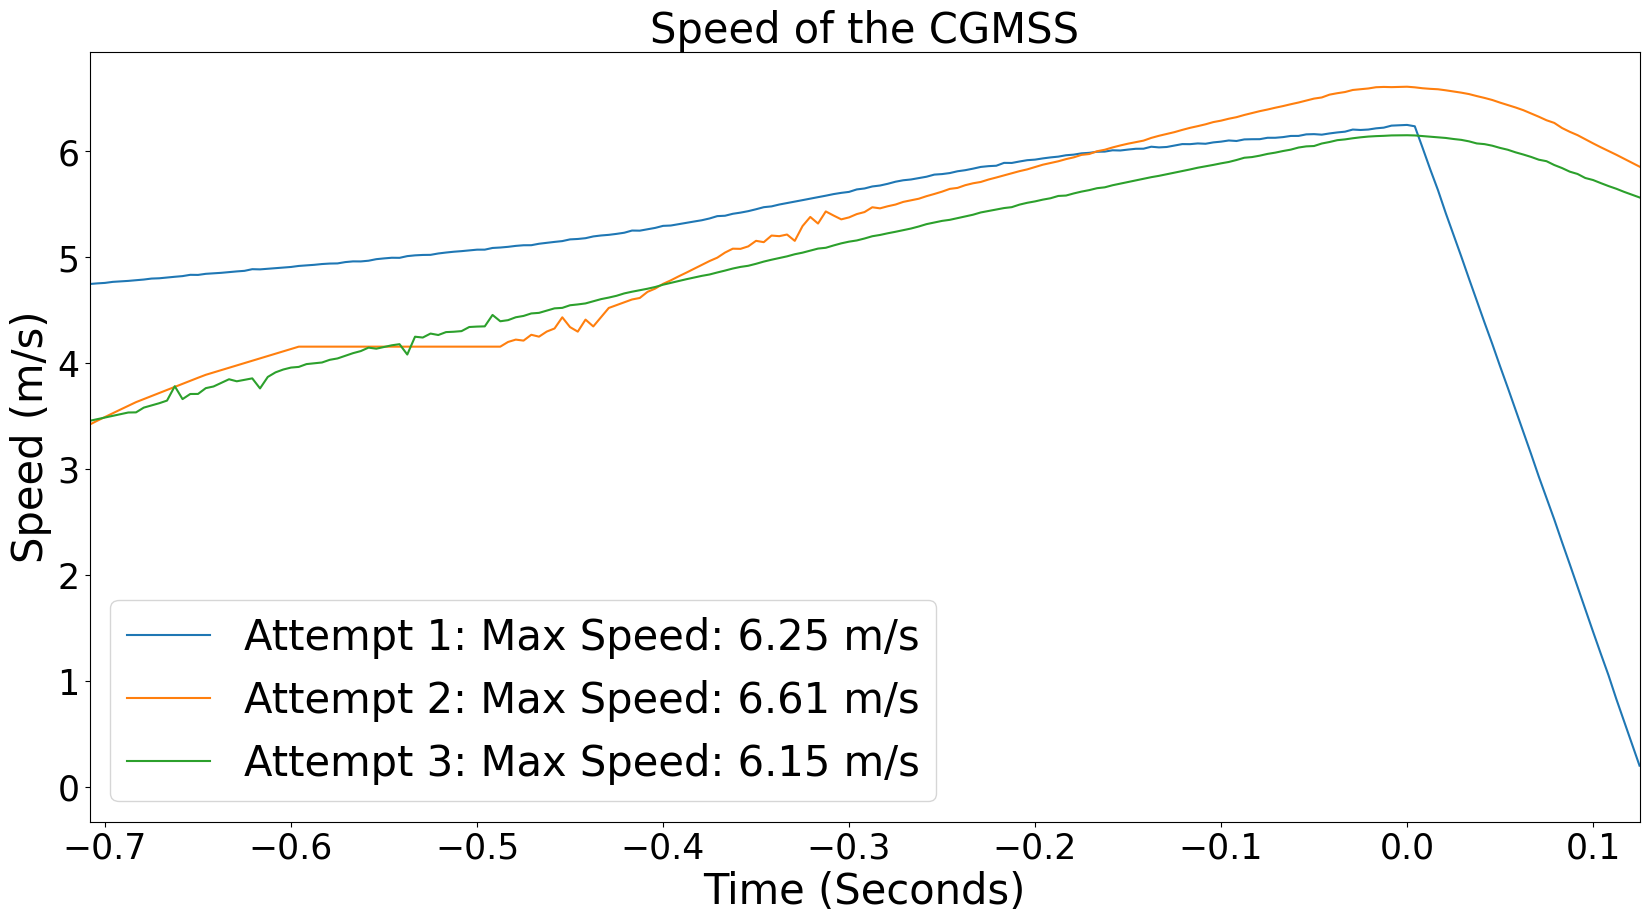

In [117]:
max_speed_df = pd.DataFrame()
for i, file in enumerate(attemps_files):
    df, frame_rate, start_time = process_csv_mocap(mocap_folder_path + file)
    df = interpolate_data(df)
    df = process_speed_accelration(df)
    #find the max speed  and it's time
    max_speed = df['x_speed_cgmss'].max()
    max_speed_time = df['Time (Seconds)'][df['x_speed_cgmss'].idxmax()]
    df['Time (Seconds)' ] = df['Time (Seconds)'] - max_speed_time
    #name column to attemps i+1 x_speed_cgmss
    df['x_speed_cgmss ' + str(i+1)] = df['x_speed_cgmss'][df['x_speed_cgmss']>0]
    #copy df to new_df only time, speed and attempt columns
    new_df = df[['Time (Seconds)','x_speed_cgmss ' + str(i+1)]]

    max_speed_df = pd.concat([max_speed_df,new_df])
plot_maxspeed(max_speed_df)

